# Test Set Evaluation

Compare classical baselines (MLP, LSTM) and quantum models on held-out test data.

**Test data:** 6 days (24 Dec 2051 to 01 Jan 2052), 224 swaption instruments.
Models predict 10 days from last training window; we evaluate first 6.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
# --- Config (must match training notebook) ---
WINDOW = 20
HORIZON = 10
VAL_SIZE = 30
DEVICE = "cpu"

# --- Load training data (need scaler + last window as model input) ---
train_df = pd.read_parquet("../data/level1.parquet")
train_df['Date'] = pd.to_datetime(train_df['Date'], format='mixed')
train_df = train_df.sort_values('Date').reset_index(drop=True)
price_cols = [c for c in train_df.columns if c != 'Date']
prices = train_df[price_cols].astype(float).values  # (494, 224)

# TODO: refactor — scaler fitting is duplicated from Classical_prediction_baseline.ipynb
# Could save/load scaler with joblib, or move to a shared utils.py
scaler = StandardScaler()
scaler.fit(prices[:-VAL_SIZE])
prices_scaled = scaler.transform(prices)

# --- Load test data (reorder cols to match training) ---
test_df = pd.read_excel("../data/test.xlsx")
test_df['Date'] = pd.to_datetime(test_df['Date'], format='mixed')
test_prices = test_df[price_cols].astype(float).values  # (6, 224)
N_TEST = len(test_prices)

print(f"Train: {prices.shape}, Test: {test_prices.shape}")
print(f"Test dates: {list(test_df['Date'].dt.strftime('%Y-%m-%d'))}")

Train: (494, 224), Test: (6, 224)
Test dates: ['2051-12-24', '2051-12-26', '2051-12-27', '2051-12-29', '2051-12-30', '2052-01-01']


## Load Models and Generate Predictions

In [3]:
# TODO: refactor — model classes are duplicated from Classical_prediction_baseline.ipynb
# Move MLP, LSTMBaseline to a shared models.py and import in both notebooks.
# We MUST define them here because torch.load(state_dict) requires the class to exist.

in_dim, out_dim = WINDOW * 224, HORIZON * 224

class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden, out_dim),
        )
    def forward(self, x): return self.net(x)

class LSTMBaseline(nn.Module):
    def __init__(self, input_dim=224, hidden_dim=64, num_layers=1, output_dim=2240):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1])

# Load saved weights
mlp_model = MLP(in_dim, out_dim).to(DEVICE)
mlp_model.load_state_dict(torch.load("../models/mlp_best.pt", weights_only=True))
mlp_model.eval()

lstm_model = LSTMBaseline().to(DEVICE)
lstm_model.load_state_dict(torch.load("../models/lstm_best.pt", weights_only=True))
lstm_model.eval()

# --- Predict on test (input = last WINDOW days of training data) ---
last_window = prices_scaled[-WINDOW:]

with torch.no_grad():
    mlp_input = torch.tensor(last_window.flatten(), dtype=torch.float32).unsqueeze(0).to(DEVICE)
    mlp_pred = scaler.inverse_transform(
        mlp_model(mlp_input).cpu().numpy().reshape(HORIZON, 224)
    )[:N_TEST]

    lstm_input = torch.tensor(last_window, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    lstm_pred = scaler.inverse_transform(
        lstm_model(lstm_input).cpu().numpy().reshape(HORIZON, 224)
    )[:N_TEST]

actual = test_prices
print(f"Predictions: MLP {mlp_pred.shape}, LSTM {lstm_pred.shape}, Actual {actual.shape}")

Predictions: MLP (6, 224), LSTM (6, 224), Actual (6, 224)


## Validation vs Test Metrics

In [4]:
# TODO: refactor — compute_metrics duplicated from baseline nb, move to utils.py
def compute_metrics(pred, actual):
    rmse = np.sqrt(((pred - actual) ** 2).mean())
    mae = np.abs(pred - actual).mean()
    eps = 1e-8
    ratio = actual / np.clip(pred, eps, None)
    qlike = (ratio - np.log(ratio) - 1).mean()
    return {'RMSE': rmse, 'MAE': mae, 'QLIKE': qlike}

# Test metrics
mlp_test = compute_metrics(mlp_pred, actual)
lstm_test = compute_metrics(lstm_pred, actual)

# Val metrics from training notebook (hardcoded — already computed there)
mlp_val = {'RMSE': 0.0162, 'MAE': 0.0120, 'QLIKE': 0.003752}
lstm_val = {'RMSE': 0.0155, 'MAE': 0.0116, 'QLIKE': 0.003293}

# Build comparison table
rows = []
for metric in ['RMSE', 'MAE', 'QLIKE']:
    rows.append({
        'Metric': metric,
        'MLP (val)': mlp_val[metric],
        'MLP (test)': mlp_test[metric],
        'LSTM (val)': lstm_val[metric],
        'LSTM (test)': lstm_test[metric],
    })

results = pd.DataFrame(rows)
results.style.format({c: '{:.6f}' for c in results.columns if c != 'Metric'}).set_caption(
    'Classical Baselines: Validation vs Test'
)

,Metric,MLP (val),MLP (test),LSTM (val),LSTM (test)
0,RMSE,0.016200,0.015962,0.015500,0.007712
1,MAE,0.012000,0.012978,0.011600,0.006434
2,QLIKE,0.003752,0.003921,0.003293,0.001081


## Test Predictions vs Actuals

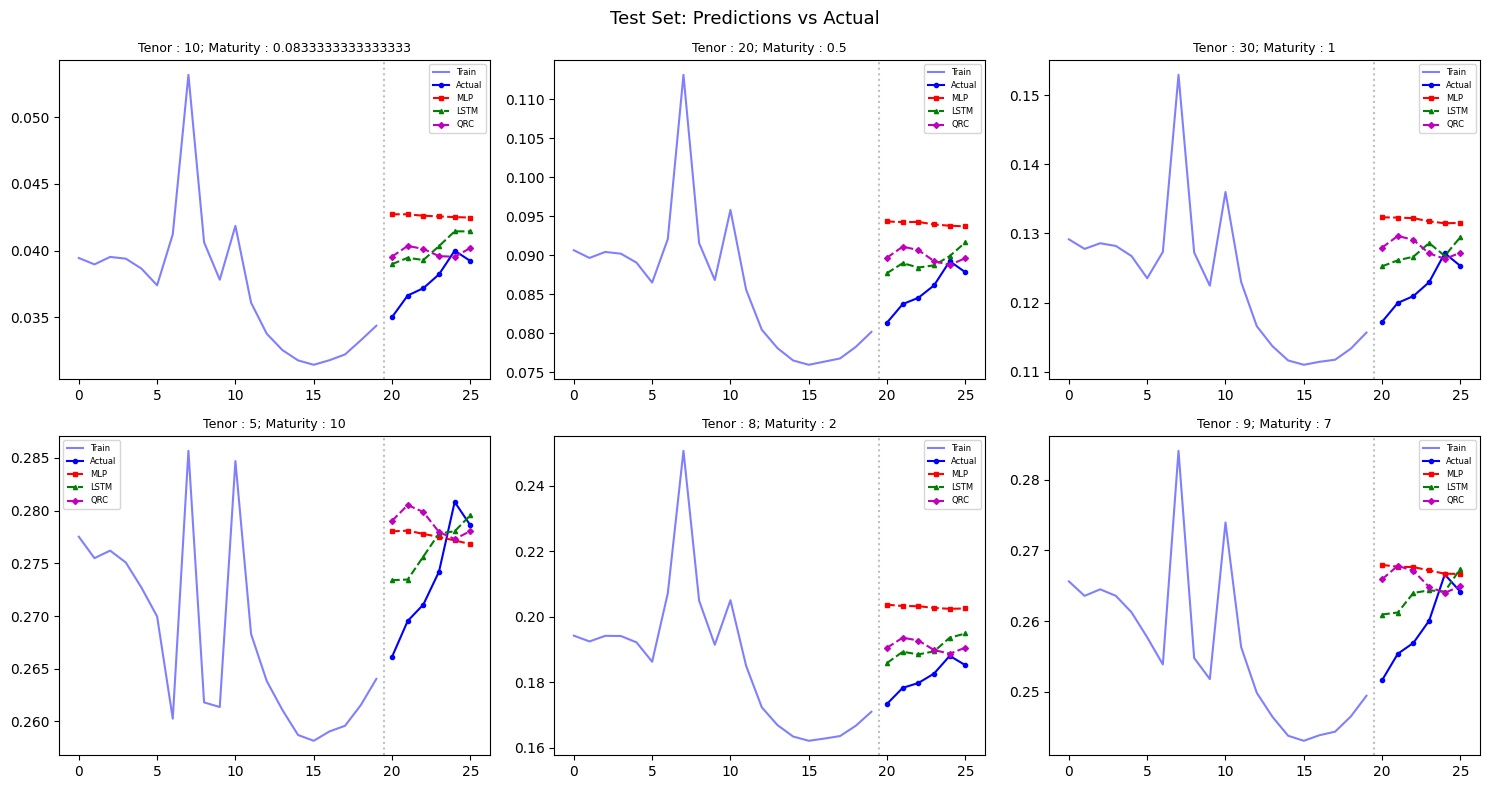

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
sample_cols = [0, 50, 100, 150, 200, 223]

for ax, col_idx in zip(axes.flat, sample_cols):
    col_name = price_cols[col_idx]
    ctx = prices[-20:, col_idx]  # last 20 training days as context
    act = actual[:, col_idx]
    x_ctx, x_test = range(20), range(20, 20 + N_TEST)
    
    ax.plot(x_ctx, ctx, 'b-', alpha=0.5, label='Train')
    ax.plot(x_test, act, 'b-o', markersize=3, label='Actual')
    ax.plot(x_test, mlp_pred[:, col_idx], 'r--s', markersize=3, label='MLP')
    ax.plot(x_test, lstm_pred[:, col_idx], 'g--^', markersize=3, label='LSTM')
    ax.plot(x_test, qrc_pred[:, col_idx], 'm--D', markersize=3, label='QRC')
    ax.axvline(19.5, color='gray', ls=':', alpha=0.5)
    ax.set_title(col_name, fontsize=9)
    ax.legend(fontsize=6)
plt.suptitle('Test Set: All Models vs Actual', fontsize=13)
plt.suptitle('Test Set: Predictions vs Actual', fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
# --- QRC Test Evaluation ---
qrc_pred = np.load("../models/qrc_test_pred.npy")  # (6, 224)
qrc_test = compute_metrics(qrc_pred, actual)
qrc_val = {'RMSE': 0.019021, 'MAE': 0.014142, 'QLIKE': 0.004899}

# Add to results table
results['QRC (val)'] = [qrc_val[m] for m in ['RMSE', 'MAE', 'QLIKE']]
results['QRC (test)'] = [qrc_test[m] for m in ['RMSE', 'MAE', 'QLIKE']]
results.style.format({c: '{:.6f}' for c in results.columns if c != 'Metric'}).set_caption(

    'All Models: Validation vs Test')

,Metric,MLP (val),MLP (test),LSTM (val),LSTM (test),QRC (val),QRC (test)
0,RMSE,0.016200,0.015962,0.015500,0.007712,0.019021,0.010582
1,MAE,0.012000,0.012978,0.011600,0.006434,0.014142,0.008368
2,QLIKE,0.003752,0.003921,0.003293,0.001081,0.004899,0.001364


In [9]:
# --- Per-day QLIKE for each model ---
eps = 1e-8
test_dates = list(test_df['Date'].dt.strftime('%Y-%m-%d'))

def qlike_per_day(pred, actual):
    """QLIKE averaged across 224 instruments, for each test day."""
    ratio = actual / np.clip(pred, eps, None)
    return (ratio - np.log(ratio) - 1).mean(axis=1)  # (N_TEST,)

qlike_rows = []
for i, date in enumerate(test_dates):
    qlike_rows.append({
        'Date': date,
        'MLP': qlike_per_day(mlp_pred, actual)[i],
        'LSTM': qlike_per_day(lstm_pred, actual)[i],
        'QRC': qlike_per_day(qrc_pred, actual)[i],
    })

qlike_df = pd.DataFrame(qlike_rows)
# Add mean row
qlike_df.loc[len(qlike_df)] = ['Mean'] + [qlike_df[c].mean() for c in ['MLP', 'LSTM', 'QRC']]

qlike_df.style.format({c: '{:.6f}' for c in ['MLP', 'LSTM', 'QRC']}).set_caption(
    'QLIKE per Test Day (lower is better)'
).apply(lambda row: ['font-weight: bold' if row['Date'] == 'Mean' else '' for _ in row], axis=1)

,Date,MLP,LSTM,QRC
0,2051-12-24,0.008283,0.002589,0.003526
1,2051-12-26,0.005066,0.001412,0.002388
2,2051-12-27,0.004125,0.000964,0.001563
3,2051-12-29,0.002725,0.000496,0.000386
4,2051-12-30,0.001404,0.000257,0.000121
5,2052-01-01,0.001924,0.000766,0.000199
6,Mean,0.003921,0.001081,0.001364
